## __What factors are associated with high streaming songs on Spotify__

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Objective
__The goal of this analysis is to identify factors associated with high Spotify streams.__

# Key Questions
- Do certain genres have higher average streams?
- Are newer songs more popular?
- Does explicit content influence popularity?
- Is popularity concentreted among a few artists?

In [32]:
df = pd.read_csv('spotify_alltime_songs.csv', na_values=['?', 'NA', '', ' '], index_col='alltime_rank')
df.head(10) 

,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
alltime_rank,,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100


In [ ]:
df.columns 

Index(['song_title', 'artist', 'total_streams_billions', 'primary_genre',
       'bpm', 'release_year', 'artist_country', 'explicit', 'danceability',
       'energy', 'valence', 'acousticness', 'dataset_part'],
      dtype='str')

In [ ]:
df.shape 

(100, 13)

In [ ]:
df.dtypes 

song_title                    str
artist                        str
total_streams_billions    float64
primary_genre                 str
bpm                         int64
release_year                int64
artist_country                str
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part                  str
dtype: object

In [6]:
df.describe() 

,total_streams_billions,bpm,release_year,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.524600,115.780000,2016.800000,0.613500,0.636100,0.550600,0.153400
std,0.851432,30.540776,7.063922,0.142888,0.163824,0.238623,0.164637
min,1.400000,62.000000,1985.000000,0.300000,0.260000,0.070000,0.000000
25%,1.735000,95.000000,2016.000000,0.520000,0.527500,0.387500,0.020000
50%,2.435000,107.000000,2018.500000,0.620000,0.650000,0.565000,0.085000
75%,3.167500,139.000000,2021.000000,0.725000,0.775000,0.732500,0.245000
max,5.260000,191.000000,2024.000000,0.900000,0.960000,0.960000,0.760000


### Data cleaning


In [ ]:
df.isna().sum()

song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

In [8]:
df.duplicated().sum() 

np.int64(0)

In [ ]:
df = df.drop('dataset_part', axis=1) #the column has no value for the analysis, it indicates which dataset is being used, but since the analysis uses only one of the datasets the column is fully redundant and to be removed

In [ ]:
df['primary_genre'].unique() #To simplify the analysis, genres will be grouped into broader categories (e.g., Pop, Hip-Hop, Rock), reducing noise from highly specific sub-genres.
df['genre'] = df['primary_genre'].str.split('/')
df = df.explode('genre')
df['genre'] = df['genre'].str.strip()
df = df.drop('primary_genre', axis=1) #removing the primary genre column

In [ ]:
df['genre'].unique() #some genres have multiple sub-genres which creates a lot of clutter, to minimize it the broader categories for genres will be created, genres with only a few songs will be combined into Others category
rap_keywords = ['rap', 'trap', 'drill']
def group_genre(x):
    x = x.lower()
    
    if any(k in x for k in ['rap', 'trap', 'drill']):
        return 'Rap'
    elif 'pop' in x:
        return 'Pop'
    elif 'rock' in x:
        return 'Rock'
    elif 'folk' in x:
        return 'Folk'
    else:
        return 'Other'

df['genre_group'] = df['genre'].str.strip().apply(group_genre)
df['genre_group'].unique() 


<StringArray>
['Pop', 'Other', 'Rock', 'Folk', 'Rap']
Length: 5, dtype: str

### Do certain genres have higher average streams?

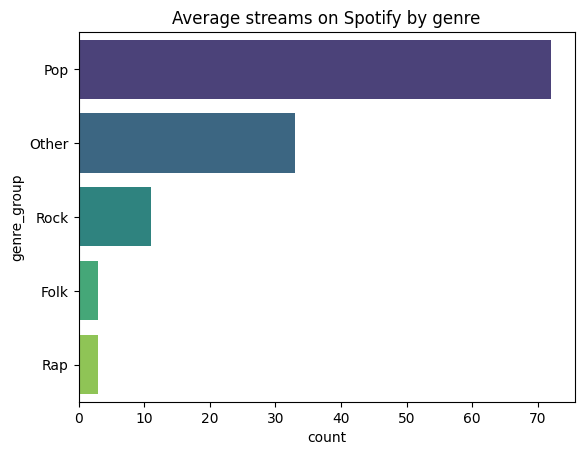

In [13]:
by_genres = df.groupby('genre_group').size().reset_index(name='count').sort_values(by='count', ascending=False)
sns.barplot(data = by_genres.head(10), x='count', y='genre_group', palette='viridis', hue='genre_group')
plt.title('Average streams on Spotify by genre')
plt.show()

In [14]:
by_genres

,genre_group,count
2,Pop,72
1,Other,33
4,Rock,11
0,Folk,3
3,Rap,3


The genre distribution is highly imbalanced, with Pop representing the vast majority of tracks (72 out of the total). Rock (11) and Hip-Hop (9) follow at much lower frequencies. In percentage terms, Pop constitutes the dominant share of the dataset, indicating a strong skew toward this genre, while other genres are relatively underrepresented.


#### Insight

- Pop songs dominate the dataset, accounting for the majority of tracks.
- This strong imbalance suggests that the dataset is heavily skewed toward a single genre, which may influence subsequent analyses (e.g., average streams by genre).

As a result, comparisons across genres should be interpreted with caution, since less represented genres (such as Rock and Hip-Hop) are based on a much smaller sample size.

### Are new songs more popular?

For the sake of consistancy the newer songs will be defined as songs that has released in the last 10 years, that is in years 2016-2026

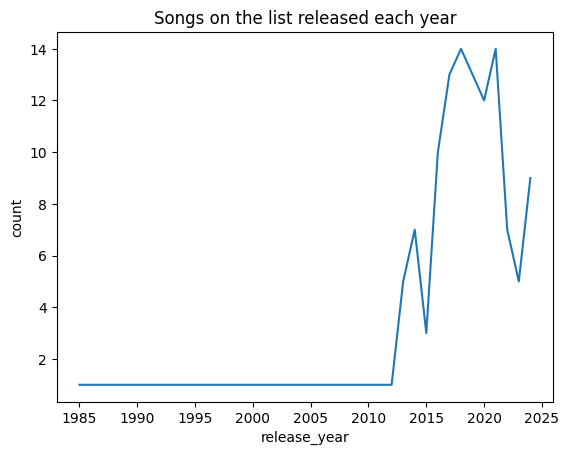

In [15]:
by_year = df.groupby('release_year').size().reset_index(name = 'count').sort_values(by = 'release_year', ascending=False)
sns.lineplot(data = by_year, x = 'release_year', y = 'count')
plt.title("Songs on the list released each year")
plt.show()

There is a visable spike in the number of songs released after year 2015 that may be linked to the rapid growth of Spotify and streaming platforms during this period. As user adoption increased, newer songs had greater exposure and more opportunities to accumulate streams.

However, this relationship cannot be directly confirmed with the available data and should be interpreted as a possible external factor rather than a causal conclusion.

In [ ]:
cutoff = 2016
before = df[df['release_year'] <= cutoff]['total_streams_billions'].sum()
after = df[df['release_year'] > cutoff]['total_streams_billions'].sum()

print(f"{(after/(before+after)* 100):.2f}% songs on the list have been released after 2016.")

73.29% songs on the list have been released after 2016.


In [ ]:
print(f'{before:.2f} bln streams - songs before 2016,\n{after:.2f} bln streams - songs after 2016\n')
print(f'Songs released after 2016 have {(after/before):.2f} times more streams than songs released before')

83.06 bln streams - songs before 2016,
227.90 bln streams - songs after 2016

Songs released after 2016 have 2.74 times more streams than songs released before


### Insight

- Songs released after 2016 have approximately 2.7× more streams than earlier tracks.  
- Additionally, over 73% of songs in the dataset were released after 2016, indicating a strong skew toward more recent releases.

This suggests that newer songs dominate the dataset of top-streamed tracks. However, this pattern is likely influenced by the rapid growth of Spotify and streaming platforms in those years, meaning the data on the list may be biased toward contemporary music rather than reflecting inherent differences in popularity.

### Does explicit content influence popularity?

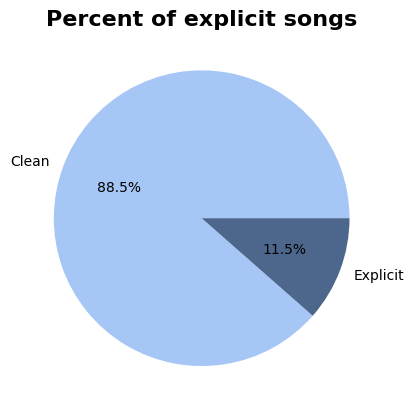

In [18]:
counts = df['explicit'].value_counts()
counts.plot(kind='pie', labels=['Clean', 'Explicit'], autopct='%1.1f%%', colors=['#a6c6f5', '#4d668c'])
plt.ylabel('') 
plt.title('Percent of explicit songs', size=16, fontweight= 'bold')
plt.show()

#### Insight

- Only 14% of songs in the dataset contain explicit lyrics, indicating that the majority of top-streamed tracks are non-explicit.

This suggests that explicit content is not a dominant characteristic of highly streamed songs. However, this pattern may be influenced by the genre distribution of the dataset. Since Pop music—typically aimed at a broad audience—accounts for the majority of tracks, the lower presence of explicit content may reflect genre characteristics rather than a direct impact on popularity.

In [19]:
df_exploded = df.assign(
    artist_country=df['artist_country'].str.split('/')
).explode('artist_country')

df_exploded[df_exploded['explicit']]['artist_country'].value_counts() 

artist_country
USA          11
Canada        2
Australia     1
Name: count, dtype: int64

#### Insight

- 11 out of 14 explicit songs are associated with artists from the USA.

However, this does not necessarily mean that songs from the USA are more likely to be explicit. This observation may simply reflect the overall dominance of US artists in the dataset.

To properly assess this relationship, the proportion of explicit songs should be compared across countries rather than relying on absolute counts.

Some songs are performed by multiple artists from different countries.  
As a result, country-level counts may exceed the total number of songs, since a single track can contribute multiple entries.

To address this, the dataset was expanded (exploded) for country-level analysis, while song-level metrics were calculated on the original dataset.

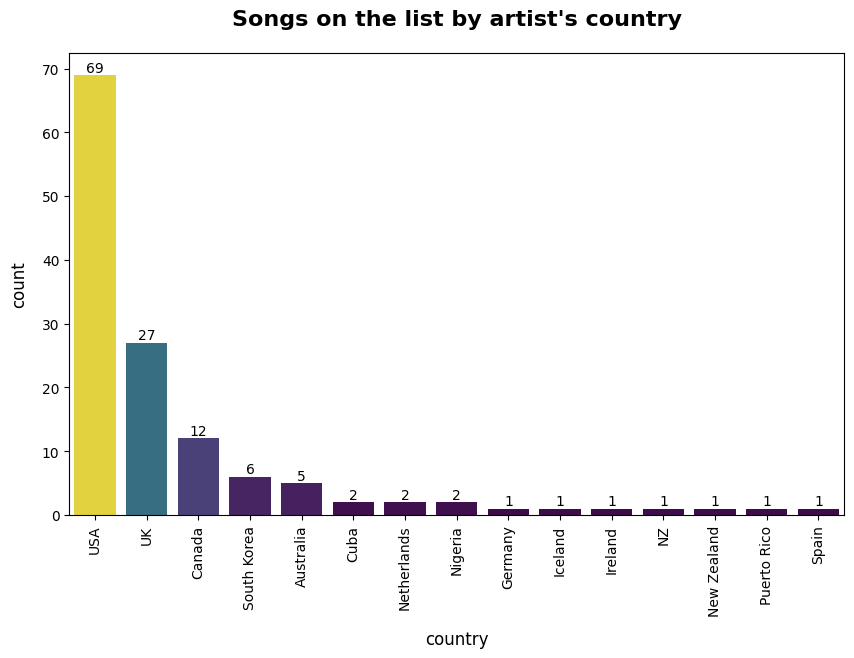

In [21]:
#counting songs originating from the USA
countries = (df_exploded.groupby('artist_country')
             .size()
             .reset_index(name='count')
             .sort_values(by='count', ascending=False))
plt.figure(figsize=(10,6))
ax = sns.barplot(data=countries,
             x='artist_country',
             y='count',
            legend=False,
            palette='viridis',
            hue='count')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,  
        height + 0.5,                 
        int(height),                  
        ha='center'                  
    )
plt.title("Songs on the list by artist's country", size=16, pad=20, fontweight='bold', loc='center')
plt.xlabel('country', size=12, labelpad=10)
plt.ylabel('count', size=12, labelpad=10)
plt.xticks(rotation=90)
plt.show()

#### Insight

- The majority of songs in the dataset are associated with artists from the United States, indicating a strong dominance of US-based performers among top-streamed tracks.

This pattern may reflect the global influence and scale of the American music industry, which has a significant presence in international markets and streaming platforms. Additionally, English-language music—predominant in the US—tends to have broader global reach, further contributing to this dominance.

However, this observation may also be influenced by dataset composition and should not be interpreted as a direct measure of artist popularity across all regions.

In [ ]:
usa = df_exploded[df_exploded['artist_country'].str.contains('US|United States', regex=True)]
canada = df_exploded[df_exploded['artist_country'] == 'Canada']

usa_ratio = usa['explicit'].sum() / len(usa)
canada_ratio = canada['explicit'].sum() / len(canada)

print(f"{usa_ratio * 100:.2f}% of songs from the USA are explicit")
print(f"{canada_ratio * 100:.0f}% of songs from Canada are explicit")

15.94% of songs from the USA are explicit
17% of songs from Canada are explicit


Country-level analysis was performed on an exploded dataset, meaning that songs with multiple artists contribute multiple entries. As a result, proportions reflect artist-country associations rather than unique songs.

#### Insight

- Approximately 15.9% of songs associated with US artists contain explicit lyrics.
- In comparison, around 17% of songs from Canadian artists are explicit.

Although the USA accounts for a larger number of explicit songs in absolute terms, its proportion of explicit tracks is very similar to that of Canada, which also has a high representation in the dataset. This indicates that the higher count of explicit songs is primarily driven by the overall presence of US artists, rather than a stronger tendency toward explicit content.

This highlights the importance of comparing proportions rather than raw counts, as relying solely on totals can lead to misleading conclusions about group behavior.

This pattern also reinforces how dataset composition can strongly influence observed trends.

In [ ]:
us_pop_ratio = df_exploded[
    df_exploded['artist_country'].str.contains('US|United States', regex=True)
]['genre_group'].value_counts(normalize=True)
us_pop_ratio

genre_group
Pop      0.565217
Other    0.275362
Rock     0.115942
Rap      0.043478
Name: proportion, dtype: float64

In [ ]:
pop_us_ratio = df_exploded[df_exploded['genre_group'] == 'Pop'][
    'artist_country'
].str.contains('US|United States', regex=True).mean()
pop_us_ratio

np.float64(0.4936708860759494)

#### Insight

- Approximately 49% of Pop songs in the dataset are associated with US artists.
- At the same time, around 57% of songs from US artists belong to the Pop genre.

This indicates a strong relationship between US artists and Pop music. While Pop is not exclusively dominated by American artists, it is the most prevalent genre among them. This overlap helps explain both the dominance of Pop in the dataset and the strong representation of US artists among top-streamed songs.

### Is popularity concentreted among a few artists?

In [ ]:
df_exploded1 = df.assign(
    artist_split=df['artist']
        .str.split(r'&|ft\.|feat\.')
        .apply(lambda x: [i.strip() for i in x if i.strip()])
).explode('artist_split')

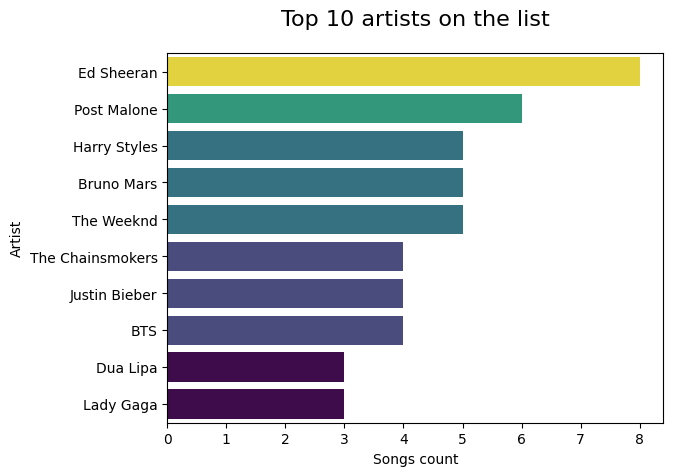

In [26]:
artist_songs = df_exploded1.groupby('artist_split').size().reset_index(name='songs').sort_values(by='songs', ascending=False)

sns.barplot(data=artist_songs.head(10), x='songs', y='artist_split', palette='viridis', hue='songs', legend=False)
plt.title('Top 10 artists on the list', fontsize=16, pad=20)
plt.xlabel('Songs count')
plt.ylabel('Artist')
plt.show()

In [ ]:
print(f'Top 10 from {artist_songs['artist_split'].count()} artists in total, are featured in {((artist_songs.head(10)['songs'].sum()) / (artist_songs['songs'].sum())* 100):.2f}% of all songs on the list.')


Top 10 from 91 artists in total, are featured in 29.19% of all songs on the list.


In [28]:
top_5_share = df['artist'].value_counts(normalize=True).head(5).sum()
print(f'Top 5 artists account for {(top_5_share * 100):.2f}% of all songs on the list.')

Top 5 artists account for 18.85% of all songs on the list.


#### Insight

- A small number of artists account for a disproportionate share of songs in the dataset, top 5 artists account for 18.85% of all songs on the list.

This indicates that song representation is concentrated among a limited group of artists rather than being evenly distributed. Such a pattern suggests that certain artists have a stronger presence among highly streamed tracks, which may reflect their popularity, industry influence, or repeated appearances in top-performing music.

## Key Findings

- The dataset is heavily skewed toward recent songs, likely reflecting the growth of streaming platforms starting around 2015.
- Pop is the dominant genre and plays a central role in overall streaming patterns.
- US artists account for the majority of songs, which may reflect the global influence and reach of the American music industry.
- There is a strong relationship between US artists and Pop music, with Pop being the most common genre among US performers.
- Explicit content does not appear to be a defining characteristic of highly streamed songs and is likely influenced more by genre than by other factors.
- Song representation is concentrated among a relatively small group of artists, with the top 5 artists accounting for nearly 19% of all songs in the dataset.

Overall, the analysis suggests that genre, geography, and platform growth are interconnected factors shaping the distribution of highly streamed songs.

## Limitations

- The dataset includes only 100 songs, limiting the generalizability of the findings.
- It represents top-streamed tracks, introducing selection bias.
- Some analyses are based on exploded data (multiple artists per song, multiple artist nationalities, multiple song genres), which may affect counts.
- External factors such as marketing, playlist placement, and listener behavior are not captured.